## DOPRINOS 1

In [9]:
referenca = """
Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech. Automatic speech recognition enables the conversion of audio signals into text and is widely used in modern applications. Deep learning based models have significantly improved the quality and speed of speech processing. The Whisper model developed by OpenAI uses neural networks trained on large datasets to enable speech recognition across many languages. Faster Whisper is an optimized implementation of the Whisper model based on the CTranslate2 library. The goal of this experiment is to analyze execution time and compare the performance of different speech recognition system implementations. Artificial intelligence continues to play an important role in speech technology, machine learning, and natural language processing. Researchers constantly develop new methods to improve accuracy, efficiency, and scalability of speech recognition systems.
"""

In [11]:
from faster_whisper import WhisperModel
from jiwer import wer

import pandas as pd
import time

In [12]:
modeli = [
    "tiny",
    "base",
    "small",
    "medium"
]

In [13]:
rezultati = []

for naziv_modela in modeli:

    print(f"\nPokreće se model: {naziv_modela}")

    model = WhisperModel(
        naziv_modela,
        device="cpu",
        compute_type="int8"
    )

    start = time.perf_counter()

    segments, info = model.transcribe(
        "audio/govor60.wav",
        language="en"
    )

    tekst = ""

    for segment in segments:
        tekst += segment.text + " "

    kraj = time.perf_counter()

    vreme = kraj - start

    greska = wer(
        referenca.lower(),
        tekst.lower()
    )

    rezultati.append({
        "Model": naziv_modela,
        "Vreme [s]": round(vreme, 2),
        "WER [%]": round(greska * 100, 2)
    })


Pokreće se model: tiny

Pokreće se model: base

Pokreće se model: small

Pokreće se model: medium


In [14]:
tabela_doprinos1 = pd.DataFrame(rezultati)

tabela_doprinos1

,Model,Vreme [s],WER [%]
0,tiny,5.11,9.93
1,base,6.60,9.22
2,small,15.52,7.09
3,medium,42.00,7.09


In [15]:
tabela_doprinos1.to_csv(
    "rezultati/doprinos1_modeli.csv",
    index=False,
    encoding="utf-8-sig"
)

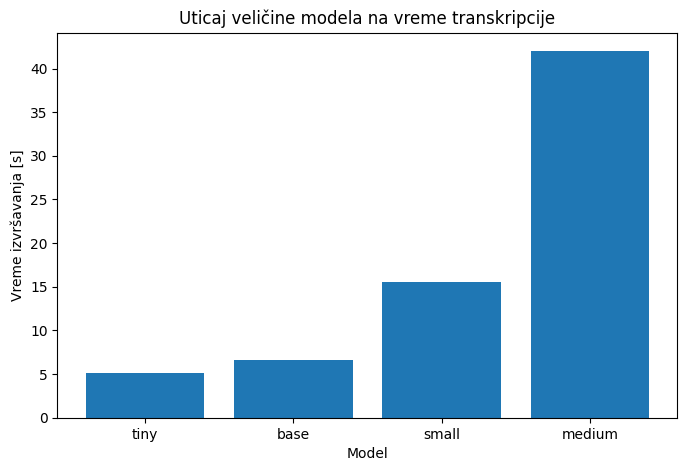

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    tabela_doprinos1["Model"],
    tabela_doprinos1["Vreme [s]"]
)

plt.xlabel("Model")
plt.ylabel("Vreme izvršavanja [s]")
plt.title("Uticaj veličine modela na vreme transkripcije")

plt.show()

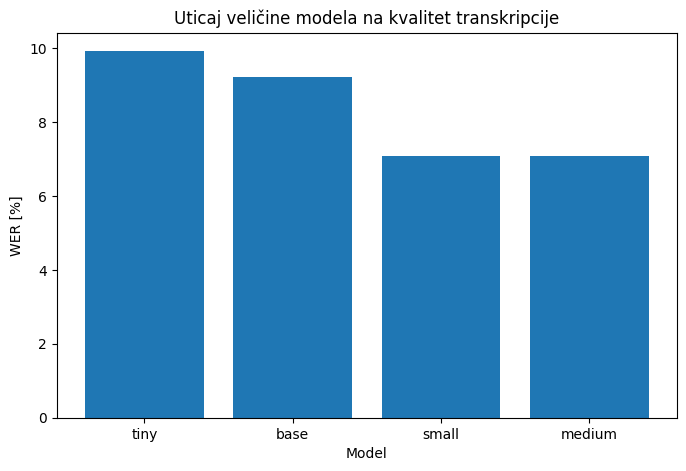

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    tabela_doprinos1["Model"],
    tabela_doprinos1["WER [%]"]
)

plt.xlabel("Model")
plt.ylabel("WER [%]")
plt.title("Uticaj veličine modela na kvalitet transkripcije")

plt.show()

## Komentar rezultata

Rezultati prikazani u tabeli pokazuju da povećanje veličine modela dovodi do povećanja vremena izvršavanja, dok istovremeno smanjuje vrednost WER metrike i poboljšava kvalitet transkripcije.

Model `tiny` ostvario je najkraće vreme izvršavanja od 5.11 s, ali i najveću stopu greške od 9.93%. Prelaskom na model `base` vreme izvršavanja povećano je na 6.60 s, dok je WER smanjen na 9.22%.

Najveće poboljšanje kvaliteta ostvareno je kod modela `small`, koji je postigao WER od 7.09%, što predstavlja značajno smanjenje greške u odnosu na modele `tiny` i `base`. Međutim, vreme izvršavanja poraslo je na 15.52 s.

Model `medium` ostvario je isto WER odstupanje od 7.09% kao i model `small`, ali uz znatno duže vreme izvršavanja od 42.00 s. Na osnovu toga može se zaključiti da povećanje veličine modela iznad nivoa `small` u ovom eksperimentu nije donelo dodatno poboljšanje kvaliteta transkripcije.

Dobijeni rezultati pokazuju da model `small` predstavlja najbolji kompromis između brzine izvršavanja i kvaliteta transkripcije za korišćeni skup podataka. Sa druge strane, model `tiny` može biti pogodan u situacijama kada je prioritet brzina rada, dok model `medium` zahteva značajno više vremena izvršavanja bez vidljivog poboljšanja WER metrike.